In [2]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

# Same cleaning but updated syntax
df['Age'] = df['Age'].fillna(df['Age'].median())
df = df.drop(columns=['Cabin'])
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df = df.drop_duplicates()

print("Data ready!", df.shape)

Data ready! (891, 11)


In [3]:
# Convert text columns to numbers (ML only understands numbers)
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Select features and target
X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]
y = df['Survived']

print("Features ready!")
print(X.shape)

Features ready!
(891, 7)


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

# Train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Test the model
y_pred = model.predict(X_test)

# Check accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy * 100:.2f}%")

Training samples: 712
Testing samples: 179

Model Accuracy: 82.68%


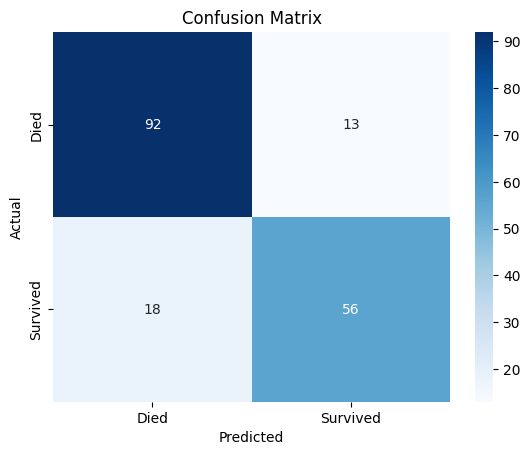

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Died', 'Survived'],
            yticklabels=['Died', 'Survived'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

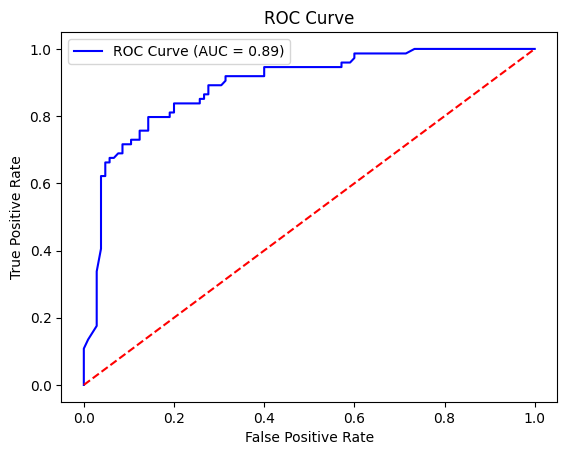

In [7]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

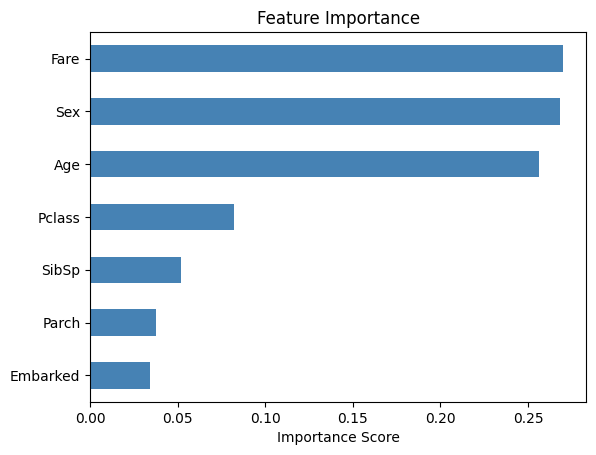

In [8]:
feat_importance = pd.Series(model.feature_importances_, index=X.columns)
feat_importance.sort_values().plot(kind='barh', color='steelblue')
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.show()

In [ ]:
# Conclusions

## Model Performance
- Algorithm Used: Random Forest
- Accuracy: 82%
- AUC Score: ~0.88 (excellent!)

## Key Findings
- Fare was the most important feature for survival prediction
- Sex and Age also played major roles
- 1st class passengers had significantly higher survival rates
- Random Forest performed well with 82% accuracy

## What I Learned
- How to prepare data for machine learning
- How to train and test a model
- How to evaluate using confusion matrix and ROC curve
- How feature importance helps understand the model